# Chaining `TrueMeasure` Transformations When Domains Are Compatible

A `TrueMeasure` transformation takes values from one set, transforms them,
and passes the result to the next transformation in a chain.

The important question is:

> **Does the next transformation need the previous range to be exactly equal
> to its domain, or does it only need every incoming value to be valid?**

This notebook shows why **containment** is the correct condition.

We first look at a simple real-world example, reproduce what the previous
QMCPy compatibility rule would do, and then show the same transformation
working with the updated rule.

## 1. A real-world picture

Suppose we model the **operating load of a battery system** as a normalized
fraction between `0` and `1`.

A downstream response model is designed to accept any normalized load

$$
x \in [0,1].
$$

However, under normal operating conditions, the battery is deliberately kept
between 25% and 75% load:

$$
x \in [0.25,0.75].
$$

There is no incompatibility here.

The downstream model accepts every value from `0` to `1`, and the upstream
stage produces only values between `0.25` and `0.75`.

Mathematically,

$$
[0.25,0.75] \subseteq [0,1].
$$

The fact that

$$
[0.25,0.75] \neq [0,1]
$$

does **not** make the two stages incompatible.

This is exactly the situation addressed by this change in QMCPy.

## 2. The mathematical compatibility condition

Consider two consecutive transformations

$$
T_{j-1}:D_{j-1}\rightarrow R_{j-1},
$$

and

$$
T_j:D_j\rightarrow R_j.
$$

The output of the first transformation becomes the input of the second:

$$
x \in R_{j-1}
\quad\longrightarrow\quad
T_j(x).
$$

Therefore, the second transformation is valid whenever **every possible
output of the first transformation lies inside the domain of the second**:

$$
\boxed{R_{j-1}\subseteq D_j}.
$$

The previous QMCPy check effectively required

$$
R_{j-1}=D_j.
$$

Equality is sufficient, but it is stronger than necessary.

For one-dimensional intervals,

$$
R_{j-1}=[r_L,r_U],
\qquad
D_j=[d_L,d_U],
$$

containment means

$$
\boxed{
d_L\le r_L
\quad\text{and}\quad
r_U\le d_U
}.
$$

For our battery example,

$$
0\le0.25
\qquad\text{and}\qquad
0.75\le1,
$$

so

$$
[0.25,0.75]\subseteq[0,1].
$$

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/true_measure_domain_inclusion.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qmcpy import DigitalNetB2, Kumaraswamy, Uniform
from qmcpy.util import ParameterError

## 3. What happened before this change?

The previous compatibility check compared the two sets using equality.

Conceptually, it asked

$$
R_{j-1}=D_j\;?
$$

For the battery example, that becomes

$$
[0.25,0.75]=[0,1]\;?
$$

which is false.

So the previous rule treated the chain as incompatible even though every
value produced by the first stage was a perfectly valid input for the second.

The code below reproduces that previous equality rule so that we can compare
it directly with the mathematically correct containment rule.

In [3]:
def previous_equality_rule(transform_range, next_domain):
    """Reproduce the previous equality-based compatibility decision."""
    transform_range = np.asarray(transform_range, dtype=float)
    next_domain = np.asarray(next_domain, dtype=float)

    try:
        transform_range, next_domain = np.broadcast_arrays(
            transform_range,
            next_domain,
        )
    except ValueError:
        return False

    return bool(np.all(transform_range == next_domain))


def containment_rule(transform_range, next_domain):
    """Check whether every transform output lies inside the next domain."""
    transform_range = np.asarray(transform_range, dtype=float)
    next_domain = np.asarray(next_domain, dtype=float)

    try:
        transform_range, next_domain = np.broadcast_arrays(
            transform_range,
            next_domain,
        )
    except ValueError:
        return False

    lower_bounds_valid = np.all(
        next_domain[:, 0] <= transform_range[:, 0]
    )
    upper_bounds_valid = np.all(
        transform_range[:, 1] <= next_domain[:, 1]
    )

    return bool(lower_bounds_valid and upper_bounds_valid)

In [4]:
battery_operating_range = np.array([[0.25, 0.75]])
response_model_domain = np.array([[0.0, 1.0]])

old_result = previous_equality_rule(
    battery_operating_range,
    response_model_domain,
)

new_result = containment_rule(
    battery_operating_range,
    response_model_domain,
)

print("Upstream operating range:", battery_operating_range)
print("Downstream accepted domain:", response_model_domain)
print()
print("Previous equality rule accepts the chain:", old_result)
print("Containment rule accepts the chain:", new_result)

Upstream operating range: [[0.25 0.75]]
Downstream accepted domain: [[0. 1.]]

Previous equality rule accepts the chain: False
Containment rule accepts the chain: True


### What does this output mean?

The two checks are answering different questions.

The previous rule asks:

> “Does the upstream stage produce **exactly the entire domain** expected by
> the downstream stage?”

and returns False because

$$
[0.25, 0.75] \neq [0, 1].
$$

The containment rule instead asks:

> “Can every value produced upstream safely be passed downstream?”

and returns True because

$$
0 \leq 0.25
\qquad \text{and} \qquad
0.75 \leq 1.
$$

Therefore,

$$
\boxed{[0.25, 0.75] \subseteq [0, 1]}.
$$

This is the behavior the PR introduces.

## 4. Now use the actual QMCPy transformation chain

We now represent the same situation using two `TrueMeasure`s.

The first transformation produces normalized operating loads in

$$
[0.25,0.75].
$$

The second transformation is a `Kumaraswamy` transformation. Its input domain
is the unit interval

$$
[0,1].
$$

A Kumaraswamy distribution is useful for quantities naturally bounded between
0 and 1, such as proportions, normalized scores, or utilization fractions.

For this example we use

$$
a=2,
\qquad
b=2.
$$

The important point for this PR is not the particular choice of distribution.
It is that the downstream transformation accepts the whole unit interval while
the upstream transformation produces only a valid subset of it.

In [5]:
inner_measure = Uniform(
    DigitalNetB2(1, randomize="FALSE"),
    lower_bound=0.25,
    upper_bound=0.75,
)

battery_response = Kumaraswamy(
    inner_measure,
    a=2.0,
    b=2.0,
)

print("Range produced by the inner transformation:")
print(inner_measure.range)

print("\nDomain accepted by the outer transformation:")
print(battery_response.domain)

print(
    "\nQMCPy reports a compatibility error:",
    battery_response.sub_compatibility_error,
)

Range produced by the inner transformation:
[[0.25 0.75]]

Domain accepted by the outer transformation:
[[0 1]]

QMCPy reports a compatibility error: False


### Why is `Compatibility error: False` the important result?

The inner transformation produces only

$$
[0.25,0.75].
$$

The outer transformation accepts

$$
[0,1].
$$

These sets are **not equal**, so the previous equality-based rule would have
marked this composition as incompatible.

With containment,

$$
[0.25,0.75]\subseteq[0,1],
$$

so QMCPy correctly allows the transformation chain.

This is the direct behavioral change introduced by the PR.

## 5. Generate values through the complete chain

Accepting the chain is useful only if it can actually be evaluated.

Let the original DigitalNet coordinate be

$$
u\in[0,1].
$$

The inner `Uniform(0.25, 0.75)` transformation is

$$
r(u)
=
0.25+(0.75-0.25)u
=
0.25+0.5u.
$$

Therefore,

$$
r(u)\in[0.25,0.75].
$$

For a Kumaraswamy distribution with parameters $a=b=2$, the CDF is

$$
F(y)=1-(1-y^2)^2,
\qquad 0\le y\le1.
$$

Its inverse CDF is

$$
F^{-1}(r)
=
\left[
1-(1-r)^{1/2}
\right]^{1/2}.
$$

The complete chained transformation is therefore

$$
\boxed{
y(u)
=
\sqrt{
1-\sqrt{
1-(0.25+0.5u)
}
}
}.
$$

The next cell compares this formula with the values produced by QMCPy.

In [6]:
sample_count = 8

# Use the same deterministic DigitalNet construction for a manual calculation.
reference_u = DigitalNetB2(
    1,
    randomize="FALSE",
).gen_samples(sample_count)

inner_values = 0.25 + 0.5 * reference_u

expected_response = np.sqrt(
    1.0 - np.sqrt(1.0 - inner_values)
)

qmcpy_response = battery_response.gen_samples(sample_count)

comparison = pd.DataFrame(
    {
        "DigitalNet u": reference_u[:, 0],
        "Operating load r(u)": inner_values[:, 0],
        "Formula result": expected_response[:, 0],
        "QMCPy result": qmcpy_response[:, 0],
    }
)

comparison

C:\Users\Owner\Downloads\QMCSoftware\qmcpy\discrete_distribution\digital_net_b2\digital_net_b2.py:675: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn(


,DigitalNet u,Operating load r(u),Formula result,QMCPy result
0,0.000,0.2500,0.366025,0.366025
1,0.500,0.5000,0.541196,0.541196
2,0.250,0.3750,0.457636,0.457636
3,0.750,0.6250,0.622597,0.622597
4,0.125,0.3125,0.413333,0.413333
5,0.625,0.5625,0.581861,0.581861
6,0.375,0.4375,0.500000,0.500000
7,0.875,0.6875,0.664066,0.664066


In [7]:
maximum_difference = np.max(
    np.abs(qmcpy_response - expected_response)
)

print(
    "Maximum difference between the mathematical formula and QMCPy:",
    f"{maximum_difference:.3e}",
)

print(
    "All generated values are finite:",
    np.isfinite(qmcpy_response).all(),
)

Maximum difference between the mathematical formula and QMCPy: 0.000e+00
All generated values are finite: True


### What did we just verify?

Each row follows the complete path

$$
u
\longrightarrow
r(u)
\longrightarrow
y(u).
$$

The first transformation converts the DigitalNet coordinate into the restricted
operating range

$$
r(u)\in[0.25,0.75].
$$

The second transformation then accepts that value because its domain is

$$
[0,1].
$$

The final comparison checks two independent calculations:

1. the closed-form mathematical expression

   $$
   y(u)
   =
   \sqrt{
   1-\sqrt{
   1-(0.25+0.5u)
   }
   },
   $$

2. the value returned by the actual QMCPy chained `TrueMeasure`.

A maximum difference near machine precision means the actual QMCPy chain is
performing the same transformation predicted by the mathematics.

So this is not only a compatibility-table change: the previously rejected
strict-subset chain can now be evaluated normally.

## 6. What output range should we expect?

Because

$$
r\in[0.25,0.75]
$$

and the Kumaraswamy inverse CDF is increasing, the smallest and largest possible
outputs occur at the two endpoints.

For $a=b=2$,

$$
y_{\min}
=
\sqrt{1-\sqrt{1-0.25}}
\approx0.3660,
$$

and

$$
y_{\max}
=
\sqrt{1-\sqrt{1-0.75}}
\approx0.7071.
$$

Therefore the composite transformation produces values approximately in

$$
\boxed{
[0.3660,\;0.7071]
}.
$$

We can check this directly with a larger point set.

In [8]:
many_samples = battery_response.gen_samples(2**12)

theoretical_minimum = np.sqrt(
    1.0 - np.sqrt(1.0 - 0.25)
)
theoretical_maximum = np.sqrt(
    1.0 - np.sqrt(1.0 - 0.75)
)

print(
    "Theoretical composite output interval:",
    f"[{theoretical_minimum:.6f}, {theoretical_maximum:.6f}]",
)

print(
    "Observed sample minimum:",
    f"{many_samples.min():.6f}",
)

print(
    "Observed sample maximum:",
    f"{many_samples.max():.6f}",
)

print(
    "Every sample lies inside the theoretical interval:",
    bool(
        np.all(many_samples >= theoretical_minimum)
        and np.all(many_samples <= theoretical_maximum)
    ),
)

Theoretical composite output interval: [0.366025, 0.707107]
Observed sample minimum: 0.366025
Observed sample maximum: 0.707020
Every sample lies inside the theoretical interval: True


C:\Users\Owner\Downloads\QMCSoftware\qmcpy\discrete_distribution\digital_net_b2\digital_net_b2.py:675: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn(


### Interpreting this output

The upstream `Uniform` transformation deliberately uses only part of the
outer transformation's valid input domain.

That restriction propagates through the second transformation and produces a
correspondingly restricted output interval.

The key point is:

$$
\text{using only part of a valid domain}
\neq
\text{being incompatible with that domain}.
$$

The downstream transformation does not require its caller to generate every
possible value in $[0,1]$.

It requires only that every value it actually receives belongs to $[0,1]$.

## 7. Visualizing why containment is enough

The outer transformation accepts the entire interval

$$
D=[0,1].
$$

The inner transformation produces

$$
R=[0.25,0.75].
$$

The figure below shows the relationship directly.

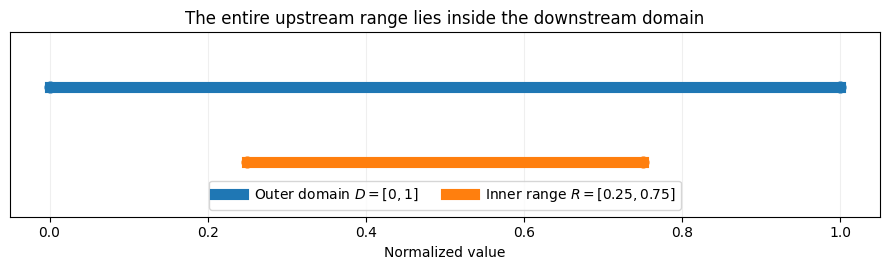

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.8))

ax.plot(
    [0, 1],
    [1, 1],
    linewidth=8,
    label=r"Outer domain $D=[0,1]$",
)

ax.plot(
    [0.25, 0.75],
    [0.65, 0.65],
    linewidth=8,
    label=r"Inner range $R=[0.25,0.75]$",
)

ax.scatter(
    [0, 1],
    [1, 1],
    s=60,
)

ax.scatter(
    [0.25, 0.75],
    [0.65, 0.65],
    s=60,
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.4, 1.25)
ax.set_yticks([])
ax.set_xlabel("Normalized value")
ax.set_title("The entire upstream range lies inside the downstream domain")
ax.legend(loc="lower center", ncol=2)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

The shorter interval does not need to cover the longer interval.

It only needs to fit inside it:

$$
\boxed{
[0.25,0.75]\subseteq[0,1]
}.
$$

That simple geometric relationship is the core of the compatibility change.

## 8. The same idea in multiple dimensions

The rule is applied coordinate by coordinate.

Suppose a system has two normalized operating quantities:

- coordinate 1 is restricted to

  $$
  [0.10,0.80],
  $$

- coordinate 2 is restricted to

  $$
  [0.20,0.90].
  $$

The next transformation accepts the unit interval in each coordinate:

$$
D=[0,1]^2.
$$

The upstream range is therefore

$$
R=
[0.10,0.80]
\times
[0.20,0.90].
$$

Compatibility requires

$$
[0.10,0.80]\subseteq[0,1]
$$

and

$$
[0.20,0.90]\subseteq[0,1].
$$

Since both conditions hold,

$$
\boxed{R\subseteq D}.
$$

In [10]:
inner_2d = Uniform(
    DigitalNetB2(2, randomize="FALSE"),
    lower_bound=[0.10, 0.20],
    upper_bound=[0.80, 0.90],
)

outer_2d = Kumaraswamy(
    inner_2d,
    a=[2.0, 2.0],
    b=[2.0, 2.0],
)

samples_2d = outer_2d.gen_samples(8)

print("Inner range:")
print(inner_2d.range)

print("\nOuter domain:")
print(outer_2d.domain)

print(
    "\nQMCPy reports a compatibility error:",
    outer_2d.sub_compatibility_error,
)

print(
    "Generated sample shape:",
    samples_2d.shape,
)

print(
    "All generated values are finite:",
    np.isfinite(samples_2d).all(),
)

Inner range:
[[0.1 0.8]
 [0.2 0.9]]

Outer domain:
[[0 1]]

QMCPy reports a compatibility error: False
Generated sample shape: (8, 2)
All generated values are finite: True


### What does the two-dimensional result show?

The inner range has one interval for each coordinate:

$$
R=
\begin{bmatrix}
0.10 & 0.80\\
0.20 & 0.90
\end{bmatrix}.
$$

The outer `Kumaraswamy` transformation uses the common unit-domain interval

$$
D=[0,1].
$$

QMCPy broadcasts that common domain across both coordinates and checks

$$
0\le0.10,\qquad0.80\le1,
$$

and

$$
0\le0.20,\qquad0.90\le1.
$$

Every coordinate passes, so the chain is compatible and samples can be
generated normally.

This demonstrates that the change applies not only to a single interval but
also to multidimensional axis-aligned boxes.

## 9. Containment does not mean “accept everything”

The new rule is less restrictive than equality, but it is not weaker in the
sense of allowing invalid inputs.

Consider an upstream transformation whose range is

$$
[-0.10,0.75].
$$

The next transformation still accepts only

$$
[0,1].
$$

Now

$$
-0.10 < 0,
$$

so part of the upstream range lies outside the downstream domain.

Therefore,

$$
[-0.10,0.75]\nsubseteq[0,1].
$$

This chain must still be rejected.

In [11]:
invalid_inner = Uniform(
    DigitalNetB2(1, randomize="FALSE"),
    lower_bound=-0.10,
    upper_bound=0.75,
)

invalid_outer = Kumaraswamy(
    invalid_inner,
    a=2.0,
    b=2.0,
)

print("Invalid inner range:")
print(invalid_inner.range)

print("\nOuter domain:")
print(invalid_outer.domain)

print(
    "\nQMCPy reports a compatibility error:",
    invalid_outer.sub_compatibility_error,
)

try:
    invalid_outer.gen_samples(8)
except ParameterError as error:
    print(
        "\nSampling is correctly rejected:"
    )
    print(type(error).__name__, "-", error)

Invalid inner range:
[[-0.1   0.75]]

Outer domain:
[[0 1]]

QMCPy reports a compatibility error: True

Sampling is correctly rejected:
ParameterError - The sub-transform range must be contained within the transform domain.


### Why is this rejection correct?

This time the problem is not merely that the two intervals are different.

The upstream transformation can actually produce values that the next
transformation does not accept.

Specifically,

$$
-0.10\notin[0,1].
$$

So the required containment condition fails:

$$
R_{j-1}\nsubseteq D_j.
$$

The updated rule therefore distinguishes the two cases correctly:

| Situation | Relationship | Result |
|---|---|---|
| Exact match | $R=D$ | Accepted |
| Smaller valid range | $R\subset D$ | Accepted |
| Range leaves domain | $R\nsubseteq D$ | Rejected |

This is the safety property we want.

## 10. General form of the rule

For a $d$-dimensional axis-aligned range,

$$
R=
\prod_{k=1}^{d}
[r_{k,L},r_{k,U}],
$$

and domain

$$
D=
\prod_{k=1}^{d}
[d_{k,L},d_{k,U}],
$$

the transformation chain is compatible exactly when

$$
\boxed{
d_{k,L}\le r_{k,L}
\quad\text{and}\quad
r_{k,U}\le d_{k,U}
\qquad
\text{for every }k=1,\ldots,d.
}
$$

This includes ordinary finite intervals as well as numerical envelopes using

$$
-\infty
\qquad\text{or}\qquad
+\infty.
$$

For example,

$$
[-5,5]\subseteq(-\infty,\infty).
$$

QMCPy represents these using numeric bounds such as `-np.inf` and `np.inf`.

This PR does not introduce representations for disconnected sets,
nonrectangular regions, or explicit open-versus-closed endpoints.

In [12]:
examples = [
    (
        "Exact equality",
        [[0.0, 1.0]],
        [[0.0, 1.0]],
    ),
    (
        "Strict subset",
        [[0.25, 0.75]],
        [[0.0, 1.0]],
    ),
    (
        "Finite interval inside real line",
        [[-5.0, 5.0]],
        [[-np.inf, np.inf]],
    ),
    (
        "Lower-bound violation",
        [[-0.10, 0.75]],
        [[0.0, 1.0]],
    ),
    (
        "Two-dimensional subset",
        [[0.10, 0.80], [0.20, 0.90]],
        [[0.0, 1.0]],
    ),
]

summary = pd.DataFrame(
    [
        {
            "Case": name,
            "Previous equality rule": previous_equality_rule(
                transform_range,
                domain,
            ),
            "Containment rule": containment_rule(
                transform_range,
                domain,
            ),
        }
        for name, transform_range, domain in examples
    ]
)

summary

,Case,Previous equality rule,Containment rule
0,Exact equality,True,True
1,Strict subset,False,True
2,Finite interval inside real line,False,True
3,Lower-bound violation,False,False
4,Two-dimensional subset,False,True


## 11. Reading the final comparison

The table summarizes exactly what changed.

### Exact equality

$$
[0,1]=[0,1].
$$

Both rules accept it.

### Strict containment

$$
[0.25,0.75]\subset[0,1].
$$

The old equality rule rejects it, while the containment rule correctly accepts
it.

### Unbounded containing domain

$$
[-5,5]\subset(-\infty,\infty).
$$

Again, equality is unnecessary; containment is sufficient.

### Genuine violation

$$
[-0.10,0.75]\nsubseteq[0,1].
$$

Both the mathematics and QMCPy's updated behavior reject it.

### Multiple dimensions

Each coordinate is checked independently, so a rectangular range can be
contained in a larger rectangular domain even when their endpoint arrays are
not identical.

## 12. Takeaway

The change can be summarized in one line:

$$
\boxed{
R_{j-1}=D_j
\quad\longrightarrow\quad
R_{j-1}\subseteq D_j
}
$$

but its practical meaning is important.

A downstream transformation should not reject an upstream transformation
simply because the upstream stage uses only part of its valid input domain.

In the battery example,

$$
[0.25,0.75]\subseteq[0,1],
$$

so every upstream value is safe to pass to the next transformation.

The previous equality-based rule would reject that composition.

The updated containment rule:

- accepts exact equality;
- accepts valid strict subsets;
- works coordinate-wise in multiple dimensions;
- supports finite and unbounded numeric envelopes;
- still rejects any range that actually leaves the next domain.

The result is a more mathematically accurate compatibility check while keeping
the safety condition intact.